In [1]:
from dataset_ae import EASGDatasetAE, EASGData
from pathlib import Path
from torch_geometric.loader import DataLoader
import torch

with open('annts_in_new_format/' + 'verbs.txt') as f:
    verbs = [l.strip() for l in f.readlines()]
num_verbs = len(verbs)

with open('annts_in_new_format/' + 'objects.txt') as f:
    objs = [l.strip() for l in f.readlines()]
num_objs = len(objs)

with open('annts_in_new_format/' + 'relationships.txt') as f:
    rels = [l.strip() for l in f.readlines()]
num_rels = len(rels)

path_annts = Path('annts_in_new_format')
path_data = Path('data')

train_original = EASGData(path_annts, path_data, 'train', verbs, objs, rels)
val_original = EASGData(path_annts, path_data, 'val', verbs, objs, rels)
train_dataset = EASGDatasetAE(path_annts, path_data, 'train', verbs, objs, rels)
val_dataset = EASGDatasetAE(path_annts, path_data, 'val', verbs, objs, rels)

batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 


In [21]:
import numpy as np
from torch.utils.data import Subset

td = train_dataset
idx = np.random.permutation(len(td))
train_size = int(0.8 * idx.size)
val_size = int(0.1 * idx.size)

train_idx = [int(i) for i in idx[:train_size]]
val_idx = [int(i) for i in idx[train_size:train_size + val_size]]
test_idx = [int(i) for i in idx[train_size + val_size:]]

# test_dataset = [td[i] for i in test_idx]

test_dataset = Subset(train_dataset, test_idx)

# Comparing ce with focal loss

In [ ]:
!python train_vae.py --output_dim=128 --beta=0.0005 --num_epochs=100 --lr_start=1e-3 --wandb --wandb_proj='vae_easg_'

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Training - exp name: VAE_od=128_kld=original_b=0.0005_lr=0.001_1718282539
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_144220-s0ye0iiz
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=0.0005_lr=0.001_1718282539
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_/runs/s0ye0iiz
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2024 14:42:26.454 Note: NumEx

In [ ]:
!python train_vae.py --output_dim=128 --beta=0.0005 --lr_start=1e-4 --wandb --wandb_proj='vae_easg_'

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Training - exp name: VAE_od=128_kld=original_b=0.0005_lr=0.0001_1718282961
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_144922-16sckm0c
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=0.0005_lr=0.0001_1718282961
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_/runs/16sckm0c
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2024 14:49:27.831 Note: Num

06/13/2024 14:49:41.569 VALIDATION EPOCH 1:
06/13/2024 14:49:41.569 acc_verb: 0.08354324097397145, balacc_verb: 0.007518796992481203
06/13/2024 14:49:41.569 topk verb accuracy [1, 2, 5, 10, 20]: 0.0835, 0.2494, 0.3564, 0.5504
06/13/2024 14:49:41.569 topk rels accuracy [1, 2, 5, 10, 20]: 0.0014, 0.0094, 0.0822, 0.6398
06/13/2024 14:49:41.569 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 45.29batch/s]
06/13/2024 14:49:59.167 VALIDATION EPOCH 5:
06/13/2024 14:49:59.168 acc_verb: 0.1658270361041142, balacc_verb: 0.007518796992481203
06/13/2024 14:49:59.168 topk verb accuracy [1, 2, 5, 10, 20]: 0.1658, 0.2494, 0.3682, 0.5504
06/13/2024 14:49:59.168 topk rels accuracy [1, 2, 5, 10, 20]: 0.3914, 0.5346, 0.6517, 0.9096
06/13/2024 14:49:59.168 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 46.09batch/s]
06/13/2024 14:50:18.017 VALIDATION EPOCH 10:
06/13/2024 14:50:18.018 acc_verb: 0.16036943744752308, balacc_verb: 0.011157969849548293
06/13/2024 14:5

In [ ]:
!python train_vae.py --output_dim=128 --beta=0.0005 --lr_start=1e-5 --wandb --wandb_proj='vae_easg_'

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Training - exp name: VAE_od=128_kld=original_b=0.0005_lr=1e-05_1718283377
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_145618-8wokpat4
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=0.0005_lr=1e-05_1718283377
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_/runs/8wokpat4
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2024 14:56:24.224 Note: NumEx

06/13/2024 14:56:38.359 VALIDATION EPOCH 1:
06/13/2024 14:56:38.359 acc_verb: 0.09529806884970612, balacc_verb: 0.009844033021700347
06/13/2024 14:56:38.359 topk verb accuracy [1, 2, 5, 10, 20]: 0.0953, 0.1675, 0.2926, 0.3489
06/13/2024 14:56:38.359 topk rels accuracy [1, 2, 5, 10, 20]: 0.1899, 0.3031, 0.4888, 0.8422
06/13/2024 14:56:38.359 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 46.59batch/s]
06/13/2024 14:56:55.774 VALIDATION EPOCH 5:
06/13/2024 14:56:55.774 acc_verb: 0.1658270361041142, balacc_verb: 0.007518796992481203
06/13/2024 14:56:55.775 topk verb accuracy [1, 2, 5, 10, 20]: 0.1658, 0.2460, 0.3984, 0.5076
06/13/2024 14:56:55.775 topk rels accuracy [1, 2, 5, 10, 20]: 0.2198, 0.3326, 0.4570, 0.8274
06/13/2024 14:56:55.775 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 44.02batch/s]
06/13/2024 14:57:14.544 VALIDATION EPOCH 10:
06/13/2024 14:57:14.544 acc_verb: 0.1658270361041142, balacc_verb: 0.007518796992481203
06/13/2024 14:57

In [ ]:
!python train_vae.py --output_dim=128 --beta=1 --lr_start=1e-3 --wandb --wandb_proj='vae_easg_'

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Training - exp name: VAE_od=128_kld=original_b=1.0_lr=0.001_1718283795
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_150316-b0dvej5u
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=1.0_lr=0.001_1718283795
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_/runs/b0dvej5u
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2024 15:03:22.410 Note: NumExpr det

06/13/2024 15:03:36.169 VALIDATION EPOCH 1:
06/13/2024 15:03:36.170 acc_verb: 0.08354324097397145, balacc_verb: 0.007518796992481203
06/13/2024 15:03:36.170 topk verb accuracy [1, 2, 5, 10, 20]: 0.0835, 0.1474, 0.3627, 0.5504
06/13/2024 15:03:36.170 topk rels accuracy [1, 2, 5, 10, 20]: 0.7485, 0.8936, 0.9328, 0.9733
06/13/2024 15:03:36.170 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 46.09batch/s]
06/13/2024 15:03:53.873 VALIDATION EPOCH 5:
06/13/2024 15:03:53.873 acc_verb: 0.08354324097397145, balacc_verb: 0.007518796992481203
06/13/2024 15:03:53.873 topk verb accuracy [1, 2, 5, 10, 20]: 0.0835, 0.2494, 0.3984, 0.5504
06/13/2024 15:03:53.873 topk rels accuracy [1, 2, 5, 10, 20]: 0.7530, 0.9273, 0.9731, 0.9949
06/13/2024 15:03:53.873 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 43.90batch/s]
06/13/2024 15:04:12.679 VALIDATION EPOCH 10:
06/13/2024 15:04:12.679 acc_verb: 0.1658270361041142, balacc_verb: 0.007518796992481203
06/13/2024 15:0

In [ ]:
!python train_vae.py --output_dim=128 --beta=1 --lr_start=1e-4 --wandb --wandb_proj='vae_easg_'

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Training - exp name: VAE_od=128_kld=original_b=1.0_lr=0.0001_1718284212
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_151013-u3vki7nj
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=1.0_lr=0.0001_1718284212
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_/runs/u3vki7nj
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2024 15:10:19.567 Note: NumExpr d

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 47.67batch/s]
06/13/2024 15:10:51.003 VALIDATION EPOCH 5:
06/13/2024 15:10:51.003 acc_verb: 0.16414777497900923, balacc_verb: 0.010170366139453837
06/13/2024 15:10:51.003 topk verb accuracy [1, 2, 5, 10, 20]: 0.1641, 0.2359, 0.4353, 0.5554
06/13/2024 15:10:51.003 topk rels accuracy [1, 2, 5, 10, 20]: 0.4962, 0.6554, 0.8157, 0.9525
06/13/2024 15:10:51.003 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 45.32batch/s]
06/13/2024 15:11:09.767 VALIDATION EPOCH 10:
06/13/2024 15:11:09.767 acc_verb: 0.14651553316540722, balacc_verb: 0.011114745355961781
06/13/2024 15:11:09.768 topk verb accuracy [1, 2, 5, 10, 20]: 0.1465, 0.2259, 0.3808, 0.5290
06/13/2024 15:11:09.768 topk rels accuracy [1, 2, 5, 10, 20]: 0.6353, 0.7832, 0.9073, 0.9741
06/13/2024 15:11:09.768 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 47.45batch/s]
06/13/2024 15:11:28.642 VALIDATION EPOCH 15:
06/13/2024 15:11:28.6

In [ ]:
!python train_vae.py --output_dim=128 --beta=1 --lr_start=1e-5 --wandb --wandb_proj='vae_easg_'

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Training - exp name: VAE_od=128_kld=original_b=1.0_lr=1e-05_1718284626
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_151707-32i54ryx
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=1.0_lr=1e-05_1718284626
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_/runs/32i54ryx
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2024 15:17:13.168 Note: NumExpr det

06/13/2024 15:17:43.567 VALIDATION EPOCH 5:
06/13/2024 15:17:43.568 acc_verb: 0.1658270361041142, balacc_verb: 0.007518796992481203
06/13/2024 15:17:43.568 topk verb accuracy [1, 2, 5, 10, 20]: 0.1658, 0.2494, 0.3564, 0.5340
06/13/2024 15:17:43.568 topk rels accuracy [1, 2, 5, 10, 20]: 0.1675, 0.2106, 0.3772, 0.5854
06/13/2024 15:17:43.568 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 43.72batch/s]
06/13/2024 15:18:02.613 VALIDATION EPOCH 10:
06/13/2024 15:18:02.614 acc_verb: 0.1658270361041142, balacc_verb: 0.007518796992481203
06/13/2024 15:18:02.614 topk verb accuracy [1, 2, 5, 10, 20]: 0.1658, 0.2494, 0.3564, 0.5504
06/13/2024 15:18:02.614 topk rels accuracy [1, 2, 5, 10, 20]: 0.3078, 0.3567, 0.5052, 0.5354
06/13/2024 15:18:02.614 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 46.87batch/s]
06/13/2024 15:18:21.276 VALIDATION EPOCH 15:
06/13/2024 15:18:21.276 acc_verb: 0.1658270361041142, balacc_verb: 0.007518796992481203
06/13/2024 15:18

## focal loss

In [ ]:
!python train_vae.py --output_dim=128 --beta=0.0005 --lr_start=1e-3 --wandb --wandb_proj='vae_easg_fl' --focal_loss

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=128_kld=original_b=0.0005_lr=0.001_1718311246
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_224047-juydruhw
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=0.0005_lr=0.001_1718311246
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_fl
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_fl/runs/juydruhw
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2024 

In [ ]:
!python train_vae.py --output_dim=128 --beta=0.0005 --lr_start=1e-4 --wandb --wandb_proj='vae_easg_fl' --focal_loss

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=128_kld=original_b=0.0005_lr=0.0001_1718311672
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_224753-3d6l1pml
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=0.0005_lr=0.0001_1718311672
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_fl2
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_fl2/runs/3d6l1pml
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2

In [ ]:
!python train_vae.py --output_dim=128 --beta=0.0005 --lr_start=1e-5 --wandb --wandb_proj='vae_easg_fl' --focal_loss

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=128_kld=original_b=0.0005_lr=1e-05_1718312098
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_225459-yknijjh8
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=0.0005_lr=1e-05_1718312098
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_fl2
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_fl2/runs/yknijjh8
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/202

In [ ]:
!python train_vae.py --output_dim=128 --beta=1 --lr_start=1e-3 --wandb --wandb_proj='vae_easg_fl' --focal_loss

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=128_kld=original_b=1.0_lr=0.001_1718312514
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_230155-kgamnko8
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=1.0_lr=0.001_1718312514
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_fl2
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_fl2/runs/kgamnko8
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2024 23:0

In [ ]:
!python train_vae.py --output_dim=128 --beta=1 --lr_start=1e-4 --wandb --wandb_proj='vae_easg_fl' --focal_loss

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=128_kld=original_b=1.0_lr=0.0001_1718312935
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_230856-oynb89ak
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=1.0_lr=0.0001_1718312935
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_fl2
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_fl2/runs/oynb89ak
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2024 23

In [ ]:
!python train_vae.py --output_dim=128 --beta=1 --lr_start=1e-5 --wandb --wandb_proj='vae_easg_fl' --focal_loss

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=128_kld=original_b=1.0_lr=1e-05_1718313363
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  $ pip install wandb --upgrade
wandb: Tracking run with wandb version 0.17.0
wandb: Run data is saved locally in /home/mscoleri/projects/easg_classification/wandb/run-20240613_231604-do1n3ln1
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run VAE_od=128_kld=original_b=1.0_lr=1e-05_1718313363
wandb: ⭐️ View project at https://wandb.ai/scoleri-mr/vae_easg_fl2
wandb: 🚀 View run at https://wandb.ai/scoleri-mr/vae_easg_fl2/runs/do1n3ln1
  0%|                                                 | 0/60 [00:00<?, ?batch/s]06/13/2024 23:1

06/13/2024 23:16:41.280 VALIDATION EPOCH 5:
06/13/2024 23:16:41.281 acc_verb: 0.1658270361041142, balacc_verb: 0.007518796992481203
06/13/2024 23:16:41.281 topk verb accuracy [1, 2, 5, 10, 20]: 0.1658, 0.2296, 0.3598, 0.5626
06/13/2024 23:16:41.281 topk rels accuracy [1, 2, 5, 10, 20]: 0.0207, 0.2075, 0.6717, 0.9154
06/13/2024 23:16:41.281 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 44.83batch/s]
06/13/2024 23:17:00.118 VALIDATION EPOCH 10:
06/13/2024 23:17:00.119 acc_verb: 0.1658270361041142, balacc_verb: 0.007518796992481203
06/13/2024 23:17:00.119 topk verb accuracy [1, 2, 5, 10, 20]: 0.1658, 0.2296, 0.3178, 0.5609
06/13/2024 23:17:00.119 topk rels accuracy [1, 2, 5, 10, 20]: 0.3027, 0.3466, 0.7699, 0.9889
06/13/2024 23:17:00.119 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 44.51batch/s]
06/13/2024 23:17:19.178 VALIDATION EPOCH 15:
06/13/2024 23:17:19.178 acc_verb: 0.15449202350965574, balacc_verb: 0.007887348284101326
06/13/2024 23:1

# Apply focal loss on rels as well

In [ ]:
!python train_vae.py --output_dim=128 --beta=1 --wandb --lr_start=1e-4  --wandb_proj='vae_easg_fl2' --focal_loss

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=128_kld=original_b=1.0_lr=0.0001_fl=True1718358840
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  

In [ ]:
!python train_vae.py --output_dim=256 --beta=1 --lr_start=1e-4 --wandb --wandb_proj='vae_easg_fl2' --focal_loss

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=256_kld=original_b=1.0_lr=0.0001_fl=True1718359270
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  

In [ ]:
!python train_vae.py --output_dim=512 --beta=1 --lr_start=1e-4 --wandb --wandb_proj='vae_easg_fl2' --focal_loss

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=512_kld=original_b=1.0_lr=0.0001_fl=True1718359702
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb:  

In [ ]:
!python train_vae.py --output_dim=128 --beta=0.0005 --lr_start=1e-4 --wandb --wandb_proj='vae_easg_fl2' --focal_loss

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=128_kld=original_b=0.0005_lr=0.0001_fl=True1718360132
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb

In [ ]:
!python train_vae.py --output_dim=256 --beta=0.0005 --lr_start=1e-4 --wandb --wandb_proj='vae_easg_fl2' --focal_loss

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=256_kld=original_b=0.0005_lr=0.0001_fl=True1718360565
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb

In [ ]:
!python train_vae.py --output_dim=512 --beta=0.0005 --lr_start=1e-4 --wandb --wandb_proj='vae_easg_fl2' --focal_loss

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=512_kld=original_b=0.0005_lr=0.0001_fl=True1718360999
wandb: Currently logged in as: scoleri-mr. Use `wandb login --relogin` to force relogin
wandb: wandb version 0.17.1 is available!  To upgrade, please run:
wandb

# Compare verb models predictions to check if/when the model predicts always the most common values

In [ ]:
import pickle
import torch
from collections import Counter

def analyze_output(output):   
    verb_indices = []
    for el in output:
        verb_indices.append(torch.topk(el, 1).indices.item())

    print(f"validation dataset has {len(verb_indices)} elements")
    count = Counter(verb_indices)
    print(count)
    print(f"Verb 'pick' with index 89 accounts for {count[89]*100/len(verb_indices)}% predictions")
    print(f"Verb 'pick-up' with index 91 accounts for {count[91]*100/len(verb_indices)}% predictions")
    print(f"Verb 'drop' with index 36 accounts for {count[36]*100/len(verb_indices)}% predictions")

## our easg classification model

In [ ]:
!python train.py --no-wandb

In [ ]:
# the above train produces the file "easg_verb_output"
with open("easg_verb_output","rb") as fp:
    out = pickle.load(fp)
analyze_output(out)

validation dataset has 2382 elements
Counter({89: 434, 91: 283, 36: 254, 58: 190, 108: 106, 174: 85, 115: 80, 1: 70, 82: 63, 177: 62, 162: 55, 103: 54, 79: 52, 193: 48, 92: 41, 12: 40, 18: 36, 173: 30, 95: 27, 69: 24, 60: 23, 104: 22, 86: 19, 102: 19, 109: 18, 26: 18, 85: 17, 30: 17, 21: 15, 98: 15, 49: 10, 66: 10, 144: 9, 105: 8, 120: 8, 10: 7, 196: 7, 122: 6, 72: 6, 63: 5, 158: 5, 111: 5, 124: 5, 119: 5, 164: 5, 52: 4, 46: 4, 175: 4, 57: 4, 112: 4, 129: 3, 34: 2, 181: 2, 13: 2, 5: 2, 170: 2, 141: 2, 16: 2, 139: 2, 126: 2, 29: 2, 154: 2, 110: 2, 90: 2, 166: 1, 157: 1, 20: 1, 155: 1, 56: 1, 83: 1, 178: 1, 176: 1, 184: 1, 148: 1, 147: 1, 84: 1, 48: 1, 15: 1, 59: 1})
Verb 'pick' with index 89 accounts for 18.21998320738875% predictions
Verb 'pick-up' with index 91 accounts for 11.880772460117548% predictions
Verb 'drop' with index 36 accounts for 10.663308144416456% predictions


## our vae model

In [ ]:
!python train_vae.py --output_dim=128 --beta=0.0005 --lr_start=1e-4

In [ ]:
# start with checking the output with standard cross entropy loss
# the above train produces the file "vae_verb_output" manually changed to "vae_verb_output_ce"
with open("vae_verb_output_ce","rb") as fp:
    out = pickle.load(fp)
out = list(torch.cat(out,dim=0))
analyze_output(out)

validation dataset has 2382 elements
Counter({89: 319, 98: 248, 91: 177, 115: 166, 36: 157, 82: 128, 30: 108, 1: 103, 162: 100, 103: 80, 58: 77, 173: 67, 12: 64, 193: 62, 49: 61, 124: 59, 108: 55, 154: 55, 102: 50, 69: 46, 85: 38, 126: 19, 178: 18, 112: 17, 79: 17, 174: 15, 34: 13, 92: 11, 18: 8, 72: 8, 177: 8, 26: 6, 29: 5, 95: 4, 197: 3, 86: 2, 104: 2, 127: 2, 4: 2, 41: 1, 120: 1})
Verb 'pick' with index 89 accounts for 13.392107472712008% predictions
Verb 'pick-up' with index 91 accounts for 7.430730478589421% predictions
Verb 'drop' with index 36 accounts for 6.591099916036944% predictions


In [ ]:
!python train_vae.py --output_dim=128 --beta=0.0005 --lr_start=1e-4  --focal_loss

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Using focal loss...
Training - exp name: VAE_od=128_kld=original_b=0.0005_lr=0.0001_1718315575
100%|████████████████████████████████████████| 60/60 [00:01<00:00, 34.81batch/s]
06/13/2024 23:53:09.840 VALIDATION EPOCH 1:
06/13/2024 23:53:09.841 acc_verb: 0.1658270361041142, balacc_verb: 0.007518796992481203
06/13/2024 23:53:09.841 topk verb accuracy [1, 2, 5, 10, 20]: 0.1658, 0.2296, 0.3665, 0.5139
06/13/2024 23:53:09.841 topk rels accuracy [1, 2, 5, 10, 20]: 0.0357, 0.1933, 0.5324, 0.9505
06/13/2024 23:53:09.841 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 45.99batch/s]
/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2184: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not

In [ ]:
# now check the output without the focal loss
# the above train produces the file "vae_verb_output" manually changed to "vae_verb_output_fl"
with open("vae_verb_output_fl","rb") as fp:
    out = pickle.load(fp)
out = list(torch.cat(out,dim=0))
analyze_output(out)

validation dataset has 2382 elements
Counter({89: 387, 36: 277, 108: 191, 91: 187, 115: 136, 58: 116, 92: 72, 79: 67, 162: 47, 98: 43, 12: 43, 18: 42, 82: 42, 103: 41, 174: 35, 95: 33, 193: 33, 85: 32, 26: 31, 30: 25, 102: 23, 124: 19, 86: 18, 46: 18, 173: 18, 60: 17, 104: 17, 69: 17, 49: 17, 166: 13, 196: 13, 129: 12, 84: 12, 177: 11, 109: 11, 164: 11, 154: 11, 105: 10, 119: 9, 13: 9, 120: 8, 57: 8, 128: 8, 21: 7, 171: 7, 144: 7, 122: 7, 157: 6, 112: 6, 10: 6, 48: 6, 65: 5, 178: 5, 114: 5, 87: 5, 63: 5, 139: 5, 153: 4, 59: 4, 126: 4, 62: 4, 52: 4, 147: 3, 160: 3, 31: 3, 189: 3, 77: 3, 188: 3, 186: 3, 133: 3, 110: 3, 29: 3, 90: 3, 158: 2, 71: 2, 51: 2, 141: 2, 146: 2, 132: 2, 195: 2, 155: 2, 72: 2, 127: 2, 67: 2, 24: 2, 143: 2, 43: 2, 181: 2, 25: 2, 33: 1, 175: 1, 101: 1, 152: 1, 148: 1, 176: 1, 150: 1, 76: 1, 151: 1, 64: 1, 187: 1, 22: 1, 121: 1, 32: 1, 1: 1, 197: 1, 135: 1, 41: 1, 184: 1, 42: 1, 156: 1, 149: 1, 130: 1, 142: 1, 88: 1})
Verb 'pick' with index 89 accounts for 16.2468513

### b=1

In [ ]:
!python train_vae.py --output_dim=128 --beta=1 --lr_start=1e-4

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 
Training dataset: 3822 samples
Validation dataset: 2382 samples
Training - exp name: VAE_od=128_kld=original_b=1.0_lr=0.0001_1718319230
100%|████████████████████████████████████████| 60/60 [00:01<00:00, 33.90batch/s]
06/14/2024 00:54:04.977 VALIDATION EPOCH 1:
06/14/2024 00:54:04.977 acc_verb: 0.16456759026028547, balacc_verb: 0.007480440175561351
06/14/2024 00:54:04.978 topk verb accuracy [1, 2, 5, 10, 20]: 0.1646, 0.2494, 0.3699, 0.5428
06/14/2024 00:54:04.978 topk rels accuracy [1, 2, 5, 10, 20]: 0.1601, 0.4385, 0.8274, 0.9326
06/14/2024 00:54:04.978 

100%|████████████████████████████████████████| 60/60 [00:01<00:00, 47.19batch/s]
06/14/2024 00:54:22.618 VALIDATION EPOCH 5:
06/14/2024 00:54:22.618 acc_verb: 0.16456759026028547, balacc_verb: 0.00967021461693003
06/14/2024 00:54:22.618 topk verb accuracy [1, 2, 5, 10, 20]: 0.1646, 0.2422, 0.3971, 0.5

In [ ]:
# start with checking the output with standard cross entropy loss
# the above train produces the file "vae_verb_output" manually changed to "vae_verb_output_ce"
with open("vae_verb_output_ce_b=1","rb") as fp:
    out = pickle.load(fp)
out = list(torch.cat(out,dim=0))
analyze_output(out)

In [ ]:
!python train_vae.py --output_dim=128 --beta=1 --lr_start=1e-4  --focal_loss

In [ ]:
# now check the output without the focal loss
# the above train produces the file "vae_verb_output" manually changed to "vae_verb_output_fl"
with open("vae_verb_output_fl_b=1","rb") as fp:
    out = pickle.load(fp)
out = list(torch.cat(out,dim=0))
analyze_output(out)

## original paper mlp 

In [ ]:
!python eval.py output_mlp/trained100epochs.pth

In [ ]:
from run_easg import EASG
model = EASG(verbs, objs, rels)
checkpoint = torch.load("output_mlp/trained100epochs.pth")
model.load_state_dict(checkpoint)
verbs_predictions = []
for idx in range(len(val_original)):
        graph = val_original[idx]
        clip_feat = graph['clip_feat'].unsqueeze(0)
        obj_feats = graph['obj_feats']

        with torch.no_grad():
            out_verb, out_objs, out_rels = model(clip_feat, obj_feats)
            verbs_predictions.append(out_verb)
with open('mlp_verb_output', 'wb') as fp:
    pickle.dump(verbs_predictions,fp)

In [ ]:
with open("mlp_verb_output","rb") as fp:
    out = pickle.load(fp)
analyze_output(out)

validation dataset has 2382 elements
Counter({89: 552, 91: 294, 58: 269, 36: 196, 12: 166, 92: 157, 103: 82, 115: 75, 82: 62, 18: 59, 108: 54, 79: 40, 1: 34, 173: 29, 86: 24, 104: 23, 164: 19, 162: 17, 193: 16, 177: 15, 166: 14, 109: 13, 48: 11, 186: 11, 30: 11, 49: 10, 124: 9, 196: 8, 69: 8, 98: 7, 21: 7, 114: 7, 102: 6, 139: 6, 174: 6, 26: 6, 178: 5, 144: 5, 63: 5, 84: 5, 171: 3, 77: 3, 188: 3, 33: 3, 10: 2, 157: 2, 133: 2, 85: 2, 195: 2, 112: 2, 148: 1, 120: 1, 56: 1, 131: 1, 154: 1, 57: 1, 111: 1, 15: 1, 52: 1, 14: 1, 16: 1, 119: 1, 110: 1, 13: 1, 126: 1})
Verb 'pick' with index 89 accounts for 23.173803526448363% predictions
Verb 'pick-up' with index 91 accounts for 12.34256926952141% predictions
Verb 'drop' with index 36 accounts for 8.228379513014273% predictions


# Checking the latent data distibution

In [ ]:
from utils import load_model, get_pred_and_gt, verb_accuracy, handle_verbs_out, to_triplets
import numpy as np
# AE
model_path_ae = 'experiments/AE1000_od=256_lr=0.0001_fl=True_ex=False_1718827741/checkpoints/last.ckpt'
ae = load_model('ae', model_path_ae)
# verbs_output_ae, verbs_gt_ae, rels_output_ae, rels_gt_ae = get_pred_and_gt('ae', ae, train_loader)

# VAE
model_path_vae = 'experiments/VAE1000_od=256_kld=original_b=0.0005_lr=0.0001_fl=True_ex=False_1718830612/checkpoints/last.ckpt'
vae = load_model('vae', model_path_vae)
# verbs_output_vae, verbs_gt_vae, rels_output_vae, rels_gt_vae = get_pred_and_gt('vae', vae, train_loader)

Using ae with focal loss...
Using vae with focal loss...


In [ ]:
latent_vae = []
for batch in train_loader:
    latent_vae.append(vae.encoder.encode_graph(batch[0])[1].squeeze().detach().numpy())

In [ ]:
latent_vae = np.array(latent_vae)
print(type(latent_vae[0]))
print(latent_vae.shape)

<class 'numpy.ndarray'>
(3822, 256)


/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


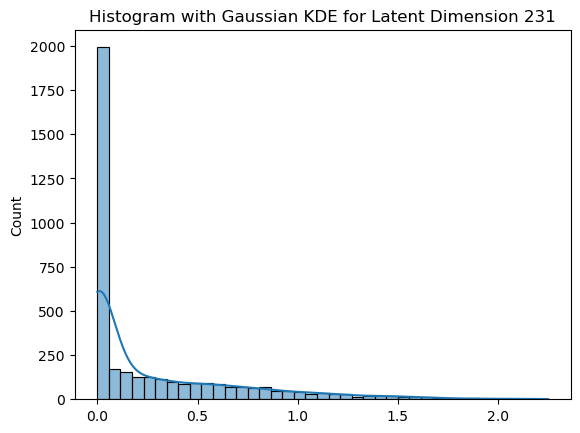

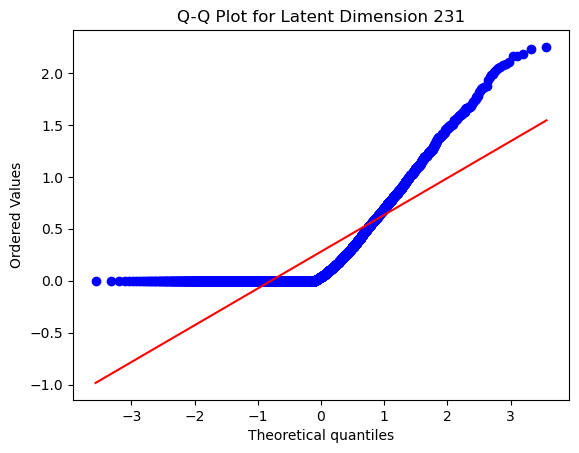

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


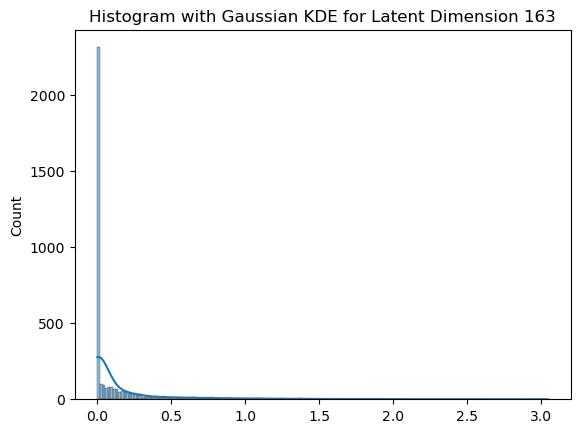

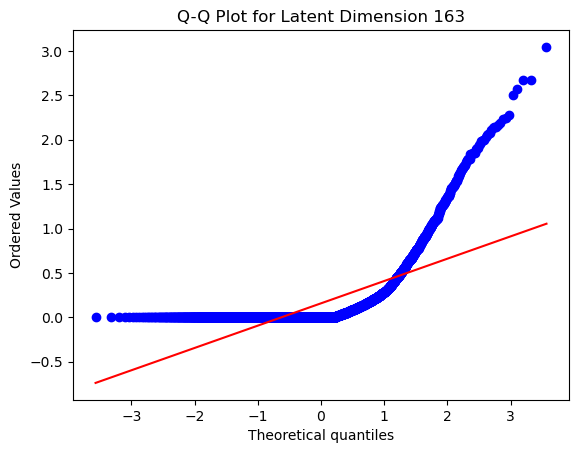

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


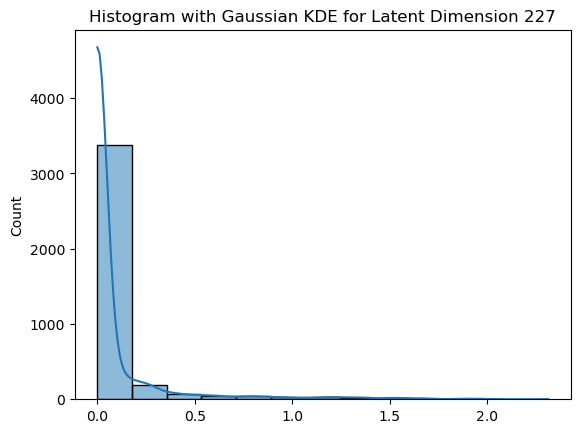

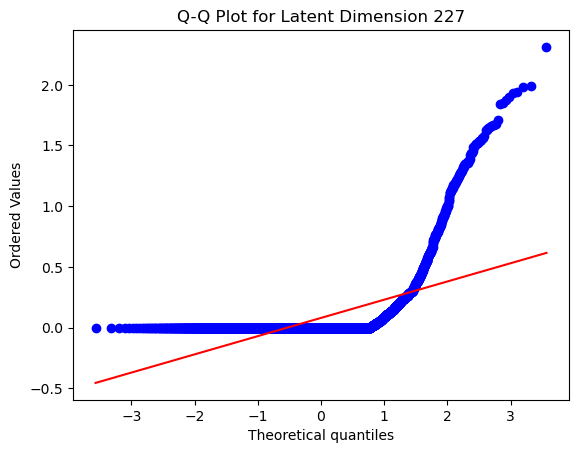

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


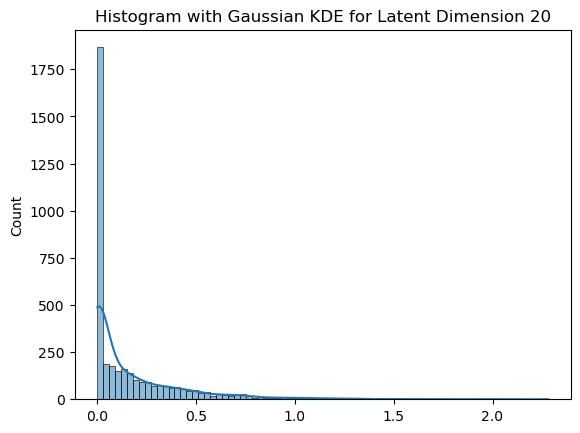

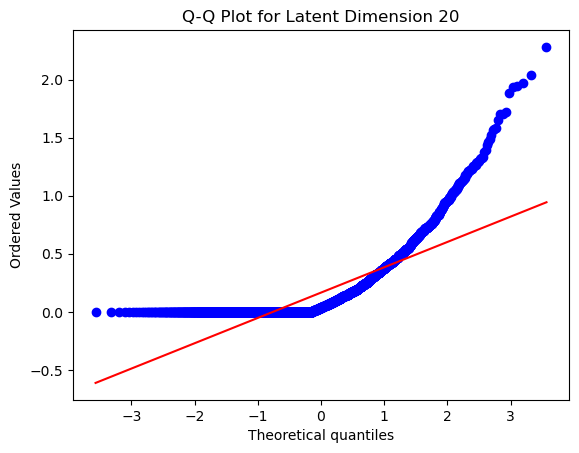

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


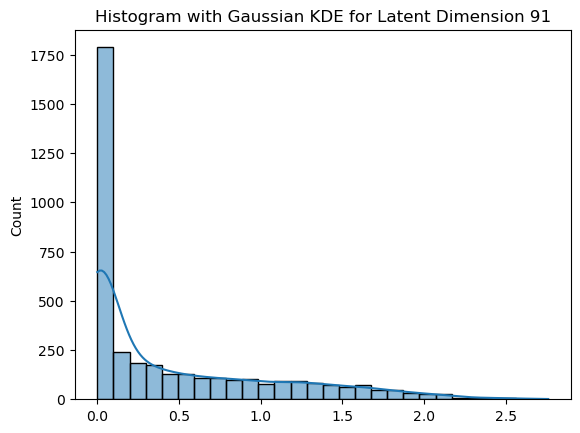

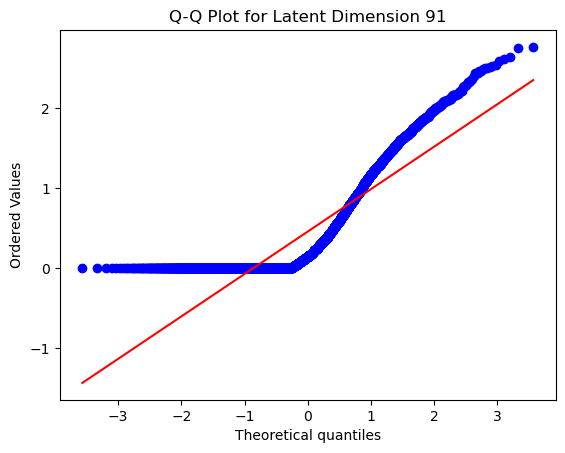

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


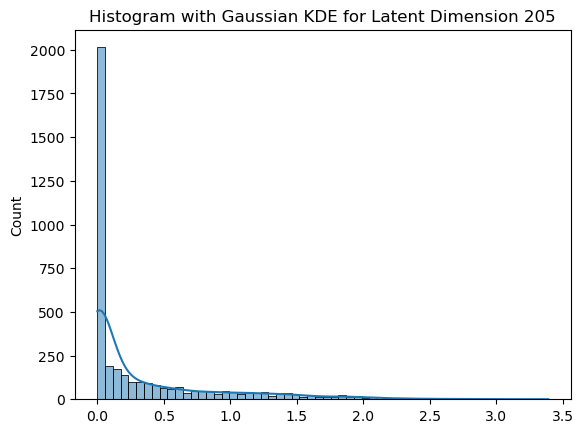

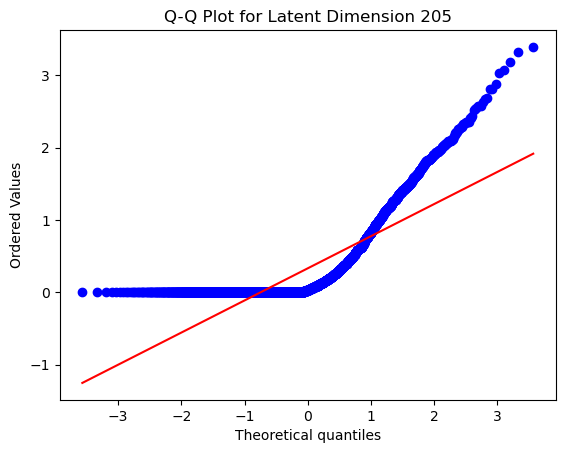

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


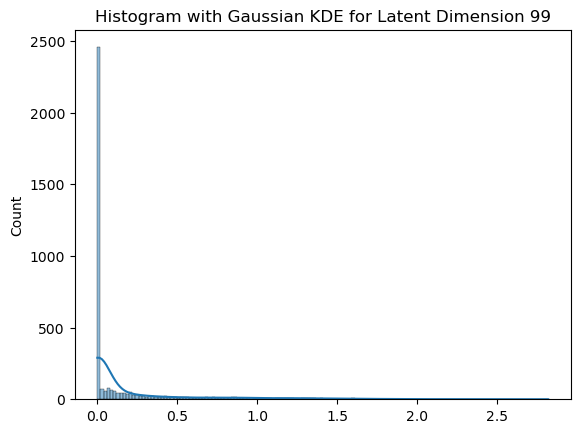

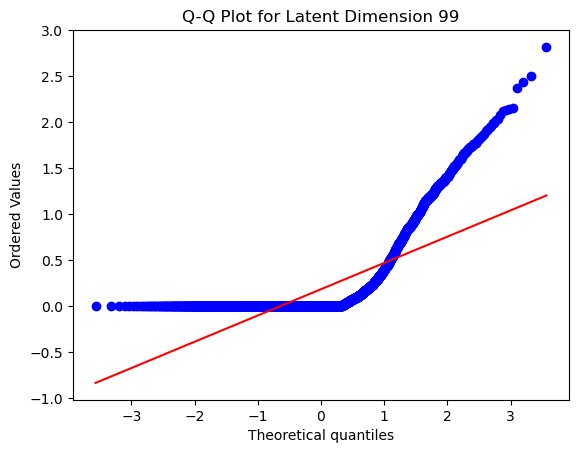

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


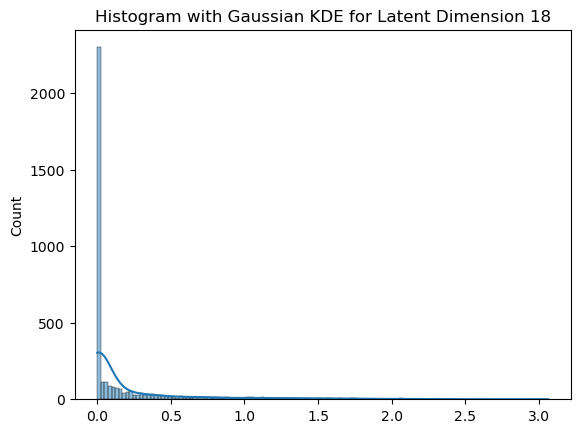

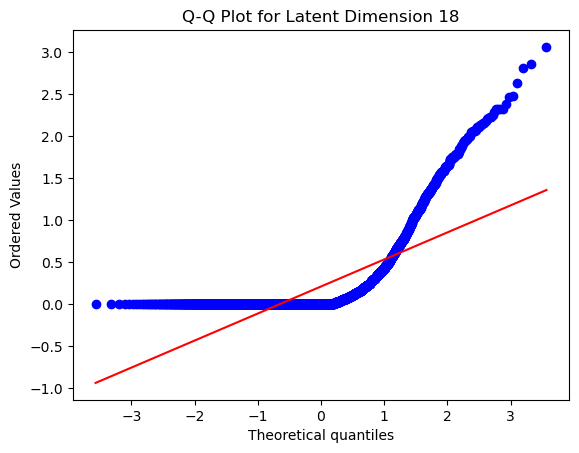

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


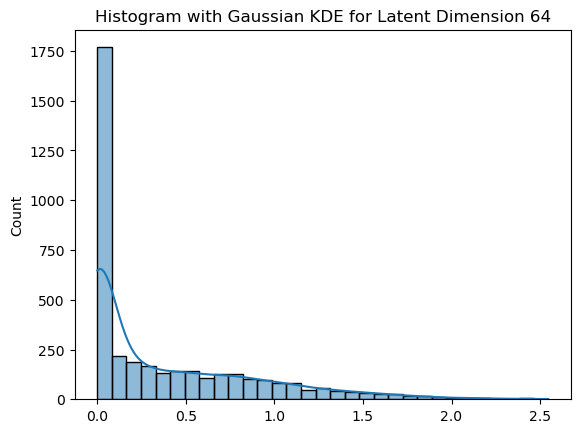

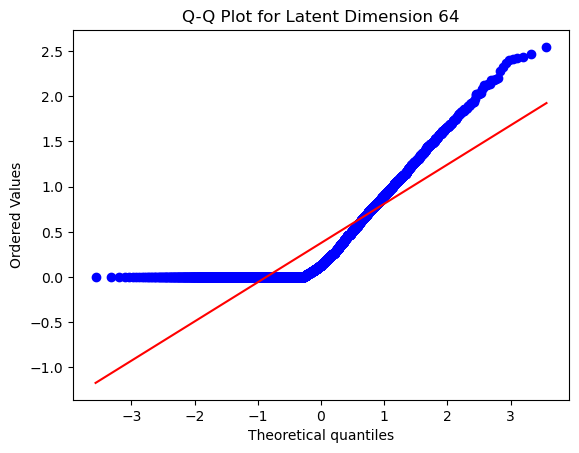

/home/mscoleri/projects/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


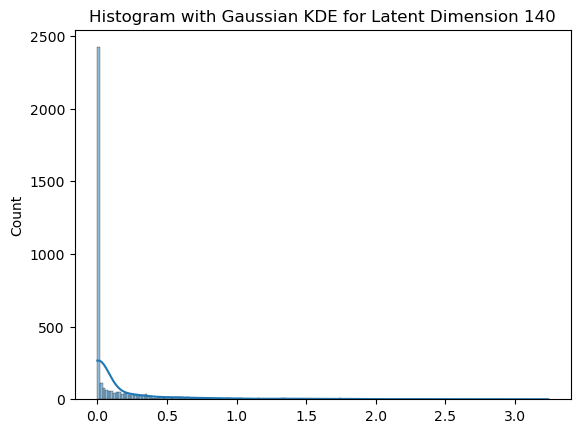

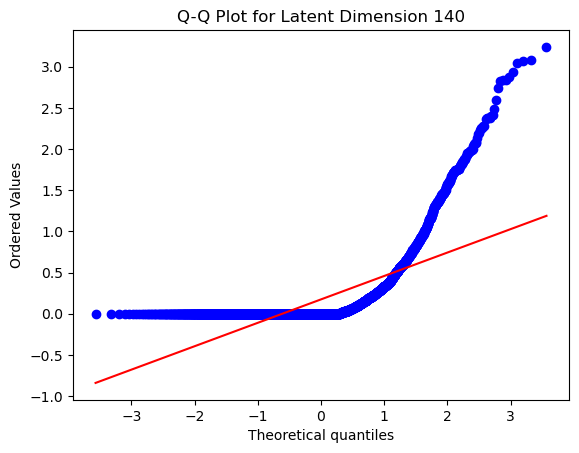

In [ ]:
# Assume z is the latent variable
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt

# Plot the distribution of latent variables
import random

latent_dim = latent_vae.shape[1]
sample_size = 10  # Number of dimensions to sample
sampled_indices = random.sample(range(latent_dim), sample_size)

for i in sampled_indices:
    sns.histplot(latent_vae[:, i], kde=True)
    plt.title(f'Histogram with Gaussian KDE for Latent Dimension {i}')
    plt.show()

    stats.probplot(latent_vae[:, i], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot for Latent Dimension {i}')
    plt.show()


# Building graphs from outputs

In [19]:
from utils import load_model, get_pred_and_gt, verb_accuracy, handle_verbs_out, to_triplets

# AE
# model_path_ae = 'experiments/AE1000_sep=True_od=256_lr=0.0001_fl=True_ex=False_1719248418/checkpoints/last.ckpt'
# ae = load_model('ae', model_path_ae, True)
# verbs_output_ae, verbs_gt_ae, rels_output_ae, rels_gt_ae = get_pred_and_gt('ae', ae, train_loader)

# VAE 1: separate=False, eps=0.1
model_path_vae = 'experiments/best_VAE1000_sep=True_od=256_kld=original_b=0.0005_lr=0.0001_fl=True_ex=False_eps=0.1_1719244127/checkpoints/last.ckpt'
vae = load_model('vae', model_path_vae, separate=True)
verbs_output_vae, verbs_gt_vae, rels_output_vae, rels_gt_vae = get_pred_and_gt('vae', vae, train_loader)

Using separate mlp for verb and rels, removing shared mlp...
Using vae with focal loss...


In [20]:
# VAE
verbs_predictions_vae = handle_verbs_out(verbs_output_vae)
print(f"{(verb_accuracy(verbs_predictions_vae, verbs_gt_vae)):.3f} %")
gt_vae, pred_vae = to_triplets(verbs_gt_vae, rels_gt_vae, verbs_output_vae, rels_output_vae)

99.843 %


In [21]:
# VAE 
# triplets that should be present but instead are predicted empty
count=0 
for el in pred_vae:
    if el.numel()==0:
        count+=1
print(f"{(count*100/len(pred_vae)):.3f} %")

0.026 %


In [22]:
correct_vae = 0
error_indices_vae = []
for i in range(len(gt_vae)):
    if gt_vae[i].size(0) == pred_vae[i].size(0):
        if torch.all((gt_vae[i] == pred_vae[i])):
            correct_vae += 1
    else:
        error_indices_vae.append(i)
print(f"{(correct_vae*100/len(gt_vae)):.2f} %")

89.04 %


In [23]:
ind = 5
print(f"gt: {gt_vae[error_indices_vae[ind]]}")
print(f"pred: {pred_vae[error_indices_vae[ind]]}")

gt: tensor([[108,  21,  12],
        [108, 211,   5],
        [108, 354,   1]])
pred: tensor([[108,  21,  12],
        [108, 354,   1]])


In [ ]:
# AE
verbs_predictions_ae = handle_verbs_out(verbs_output_ae)
print(f"{(verb_accuracy(verbs_predictions_ae, verbs_gt_ae)):.3f} %")
gt_ae, pred_ae = to_triplets(verbs_gt_ae, rels_gt_ae, verbs_output_ae, rels_output_ae)

In [5]:
correct_ae = 0
error_indices_ae = []
for i in range(len(gt_ae)):
    if gt_ae[i].size(0) == pred_ae[i].size(0):
        if torch.all((gt_ae[i] == pred_ae[i])):
            correct_ae += 1
    else:
        error_indices_ae.append(i)
print(f"{(correct_ae*100/len(gt_ae)):.2f} %")

99.69 %


# Video identification
In the paper's folder there is a file called 'ALL_GRAPHS_FOR_DOWNSTREAM.json' where we can find all the videos ids. These ID's are part of the frame ID that we can find in the annotations in "annts_in_new_format" and in the object/clip features in the "data" folder

### First collect all the video IDs from the json

In [1]:
import json
f = open('ALL_GRAPHS_FOR_DOWNSTREAM.json')
all_graphs = json.load(f)

videos_uid = []
for key, value in all_graphs.items():
    videos_uid.append(all_graphs[key]['video_uid'])
# these videos_uid coincide with the keys of graphs

### Now get all the annotations present in the train and test folders
We need to check how many times these video IDs appear in the annotations to know how many annotated frames we have for each video

In [2]:
# get all the annotated frames from annts in new format 
# NB these annotations ids would be the same if obtained from the files easg_train.pkl and easg_val.pkl in the "data"
import pickle
import numpy as np
import pandas as pd

path_annts = 'annts_in_new_format/'
with open(path_annts + f'easg_train.pkl', 'rb') as f:
    annts_train = pickle.load(f)

with open(path_annts + f'easg_val.pkl', 'rb') as f:
    annts_val = pickle.load(f)

frames_ids = list(annts_train.keys()) + list(annts_val.keys())

In [3]:
def check_partial_key(video_id, frames_ids):
    ''' find, if present, the given video ID in the list of given annotations IDs.
    Return the index in the frames_ids in which we found the video_id'''
    match_indices = []
    for el in frames_ids:
        if video_id in el:
            match_indices.append(frames_ids.index(el))
    return match_indices

In [4]:
annotations_per_video = []
for el in all_graphs:
    res = check_partial_key(el, frames_ids)
    annotations_per_video.append(len(res))
ann_per_video = np.array(annotations_per_video)
print(len(ann_per_video))
print(sorted(ann_per_video))
ann_per_video_series = pd.value_counts(ann_per_video)

221
[1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 13, 13, 13, 14, 14, 14, 15, 15, 15, 15, 15, 15, 16, 16, 16, 17, 17, 17, 17, 17, 17, 18, 18, 18, 19, 19, 19, 19, 19, 20, 20, 20, 20, 21, 21, 21, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23, 23, 25, 26, 26, 27, 27, 27, 27, 27, 27, 27, 27, 28, 28, 29, 30, 30, 30, 31, 31, 31, 31, 31, 31, 32, 32, 32, 33, 33, 33, 33, 34, 34, 34, 34, 35, 35, 35, 35, 36, 36, 37, 38, 39, 39, 39, 41, 43, 43, 43, 43, 43, 44, 45, 46, 47, 47, 48, 48, 49, 50, 50, 51, 52, 54, 55, 55, 56, 57, 59, 63, 69, 70, 73, 74, 77, 78, 78, 83, 85, 86, 86, 87, 92, 92, 92, 102, 105, 113, 122, 132, 153, 208]


Text(0, 0.5, 'Frequency')

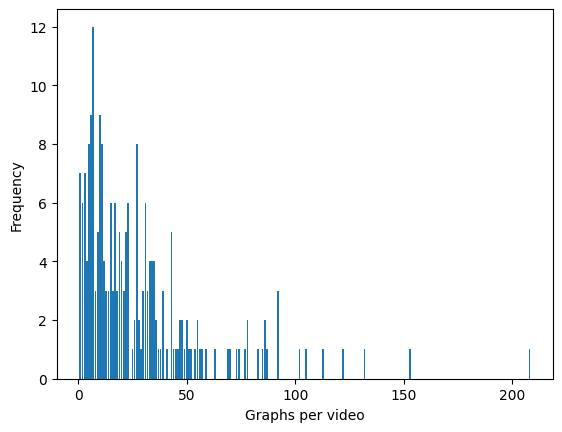

In [5]:
import matplotlib.pyplot as plt
plt.bar(ann_per_video_series.index, ann_per_video_series.values)
plt.xlabel('Graphs per video')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

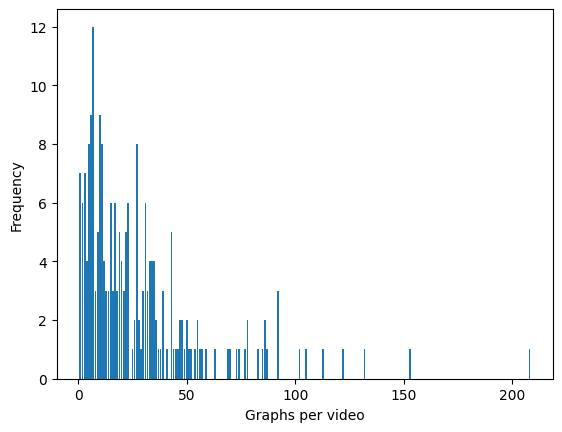

In [ ]:
import matplotlib.pyplot as plt
plt.bar(ann_per_video_series.index, ann_per_video_series.values)
plt.xlabel('Graphs per video')
plt.ylabel('Frequency')

In [6]:
print(f'Total videos: {ann_per_video_series.sum()}')
print(f'Graphs with more than 5 videos: {ann_per_video_series.loc[ann_per_video_series.index>5].sum()}')
print(f'Graphs with more than 10 videos: {ann_per_video_series.loc[ann_per_video_series.index>10].sum()}')
print(f'Graphs with more than 20 videos: {ann_per_video_series.loc[ann_per_video_series.index>20].sum()}')
print(f'Graphs with more than 50 videos: {ann_per_video_series.loc[ann_per_video_series.index>50].sum()}')

Total videos: 221
Graphs with more than 5 videos: 189
Graphs with more than 10 videos: 151
Graphs with more than 20 videos: 106
Graphs with more than 50 videos: 31


In [13]:
# number of graphs statistics
print(f'min number of graphs per video: {np.min(annotations_per_video)}')
print(f'max number of graphs per video: {np.max(annotations_per_video)}')
print(f'average number of graphs per video: {np.mean(annotations_per_video)}')
print(f'std of number of graphs per video: {np.std(annotations_per_video)}')

min number of graphs per video: 1
max number of graphs per video: 208
average number of graphs per video: 28.058823529411764
std of number of graphs per video: 29.112687543259938


### WARNING: the list annotations_per_video should be the same if obtained directly from the json but actually they are slightly different:

In [42]:
annotations_per_video_json = []
for graph_uid in all_graphs:
    annotations_per_video_json.append(len(all_graphs[graph_uid]['graphs']))

In [59]:
print(sorted(annotations_per_video_json) == sorted(annotations_per_video))

ann_per_video = np.array(sorted(annotations_per_video))
ann_per_video_series = pd.value_counts(ann_per_video)

ann_per_video_json = np.array(sorted(annotations_per_video_json))
ann_per_video_series_json = pd.value_counts(ann_per_video)

print((ann_per_video_series == ann_per_video_series_json).sum())
print(len(annotations_per_video_json))

False
73
221


/tmp/ipykernel_240250/55638186.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  ann_per_video_series = pd.value_counts(ann_per_video)
/tmp/ipykernel_240250/55638186.py:7: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  ann_per_video_series_json = pd.value_counts(ann_per_video)


# Diffusion

Train example:
!python train_diffusion.py --train_denoiser --epochs_denoise=1000 --timesteps=500 --wandb --n_layers_denoise=8

In [3]:
from dataset_ae import EASGDatasetAE, EASGData
from pathlib import Path
from torch_geometric.loader import DataLoader
import torch

with open('annts_in_new_format/' + 'verbs.txt') as f:
    verbs = [l.strip() for l in f.readlines()]
num_verbs = len(verbs)

with open('annts_in_new_format/' + 'objects.txt') as f:
    objs = [l.strip() for l in f.readlines()]
num_objs = len(objs)

with open('annts_in_new_format/' + 'relationships.txt') as f:
    rels = [l.strip() for l in f.readlines()]
num_rels = len(rels)

path_annts = Path('annts_in_new_format')
path_data = Path('data')

train_original = EASGData(path_annts, path_data, 'train', verbs, objs, rels)
val_original = EASGData(path_annts, path_data, 'val', verbs, objs, rels)
train_dataset = EASGDatasetAE(path_annts, path_data, 'train', verbs, objs, rels)
val_dataset = EASGDatasetAE(path_annts, path_data, 'val', verbs, objs, rels)

batch_size = 1
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

triplets_original = [train_original[i]['triplets'] for i in range(len(train_original))]

device = 'cuda' if torch.cuda.is_available() else 'cpu'
all_clip_features = torch.vstack([el[0].x[0] for el in train_dataset]).to(device)

EASGDatasetAE - train - num_objs: 391, num_verbs: 198, num_rels: 13 
EASGDatasetAE - val - num_objs: 391, num_verbs: 198, num_rels: 13 


## Evaluate diffusion samples from random noise

In [43]:
def find_checkpoint(parent_folder, end):
    import os
    subfolders = [name for name in os.listdir(parent_folder) if os.path.isdir(os.path.join(parent_folder, name))]
    matching_subfolders = [subfolder for subfolder in subfolders if subfolder.endswith(str(end))]
    
    if len(matching_subfolders)>0:
        return parent_folder+matching_subfolders[0]+'/checkpoints/last.ckpt'
    else:
        return None

In [69]:
from denoise_model import DenoiseNN
from utils_diffusion import get_denoised_samples
from utils import load_model, get_pred_triplets
import torch

diff_path = find_checkpoint('experiments/diffusion_cond/', 7155)
print(diff_path)
n_layers = 3
norm_type = 'layer'
latent_dim = 256
cond = all_clip_features

if cond is not None:
    n_properties = 2304
    d_cond = 1024
else:
    n_properties = 0
    d_cond = 0

# LOAD THE DIFFUSION MODEL AND GET SAMPLES
denoised_samples = get_denoised_samples(diff_path, latent_dim=latent_dim, timesteps=1000, num_samples=10000, n_layers=n_layers, norm_type=norm_type, n_properties=n_properties, dim_cond=d_cond, cond=cond)

# LOAD THE DECODER FROM TRAINED VAE AND GET DECODED SAMPLES
if latent_dim == 512:
    vae_path = 'experiments/best_VAE1000_sep=True_fromae=False_od=512_kld=original_b=0.0005_lr=0.0001_fl=True_ex=False_eps=0.1_1722873332/checkpoints/last.ckpt'
elif latent_dim == 256:
    vae_path = 'experiments/best_VAE1000_sep=True_od=256_kld=original_b=0.0005_lr=0.0001_fl=True_ex=False_eps=0.1_1719244127/checkpoints/last.ckpt'
vae = load_model('vae', vae_path, separate=True, output_dim=latent_dim)
decoder = vae.decoder.to(device)
decoded_samples = decoder(denoised_samples)

# GET THE TRIPLETS FROM THE DECODED SAMPLES
triplets_diffusion = get_pred_triplets(decoded_samples[0], decoded_samples[1])

experiments/diffusion_cond/diffusion_tsteps=1000_nlayer=3_ldim=256_lr=0.0001_sch=warmup_loss=huber_dcond=1024_1723427155/checkpoints/last.ckpt
Using separate mlp for verb and rels, removing shared mlp...
Using vae with focal loss...


### Check average number of objects for each graph
Compare the average number of objects for each graph given as output by the diffusion model with the original train dataset

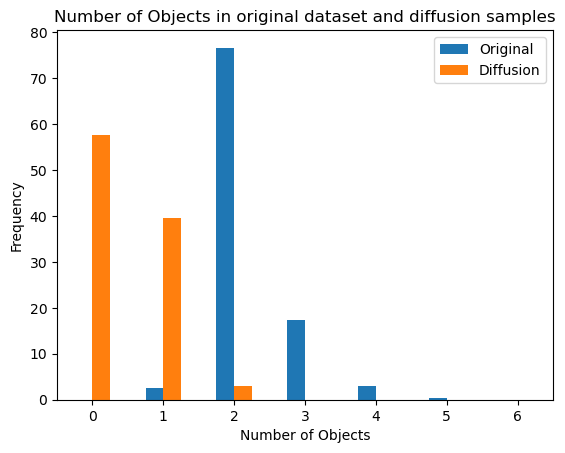

In [70]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the number of objects in each training and validation sample
num_objects_train = [triplets_original[i].size(0) for i in range(len(triplets_original))]
num_objects_diff = [triplets_diffusion[i].size(0) for i in range(len(triplets_diffusion))]

# Convert to pandas Series
objects_train_pd = pd.Series(num_objects_train, name='Train')
objects_diff_pd = pd.Series(num_objects_diff, name='Diffusion')

# Get value counts and sort by index
objects_train_count = objects_train_pd.value_counts().sort_index()
objects_train_count = objects_train_count*100/objects_train_count.sum()

objects_diff_count = objects_diff_pd.value_counts().sort_index()
objects_diff_count = objects_diff_count*100/objects_diff_count.sum()

# Combine both Series into a DataFrame
objects_count_df = pd.DataFrame({'Original': objects_train_count, 'Diffusion': objects_diff_count}).fillna(0)

objects_count_df.plot.bar()
plt.xticks(rotation=0)
plt.title('Number of Objects in original dataset and diffusion samples')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency')
plt.show()


In [71]:
# Initialize counters
count_0 = 0
count_1 = 0
count_2 = 0
count_3 = 0

# Loop through triplets_diffusion once
for el in triplets_diffusion:
    triplet_size = el.size(0)
    if triplet_size == 0:
        count_0 += 1
    elif triplet_size == 1:
        count_1 += 1
    elif triplet_size == 2:
        count_2 += 1
    elif triplet_size == 3:
        count_3 += 1

# Total number of elements
total = len(triplets_diffusion)

# Print the percentages
print(f'{(count_0 * 100 / total):.2f} % of graphs result in empty triplets')
print(f'{(count_1 * 100 / total):.2f} % of graphs have 1 triplet')
print(f'{(count_2 * 100 / total):.2f} % of graphs have 2 triplets')
print(f'{(count_3 * 100 / total):.2f} % of graphs have 3 triplets')

57.54 % of graphs result in empty triplets
39.53 % of graphs have 1 triplet
2.89 % of graphs have 2 triplets
0.04 % of graphs have 3 triplets


### Check the verbs distribution comparing original dataset and diffusion samples

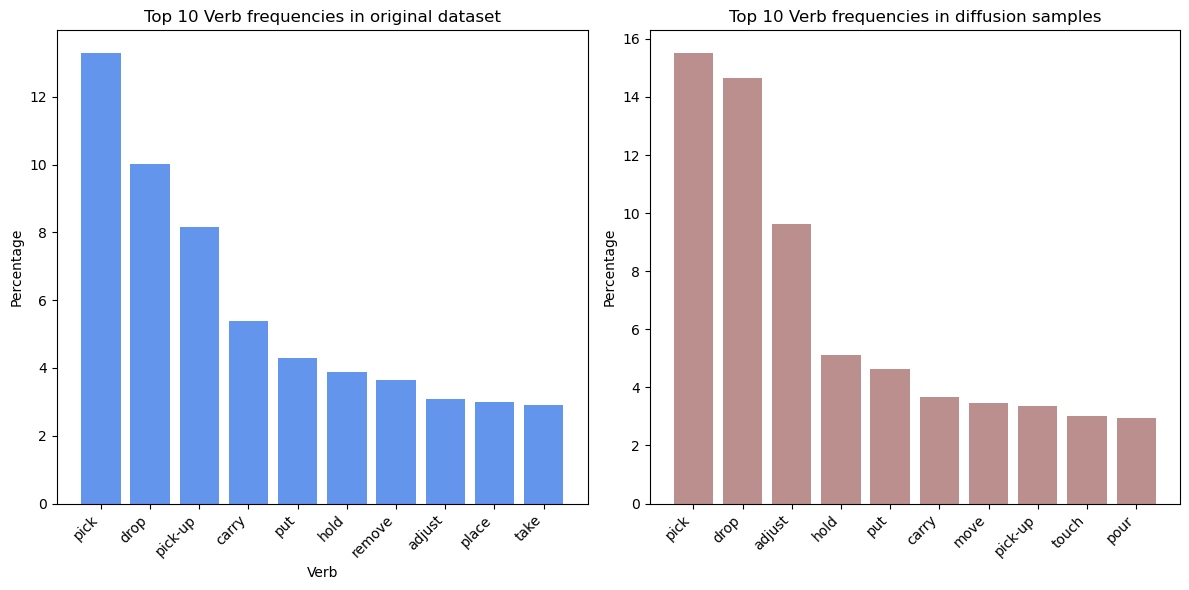

In [72]:
from utils import compare_statistics
verbs_list_original = [triplet[0].item() for triplets in triplets_original for triplet in triplets]
verbs_list_diffusion = [triplet[0].item() for triplets in triplets_diffusion for triplet in triplets]

compare_statistics(verbs_list_original, verbs_list_diffusion, verbs, 'original dataset', 'diffusion samples', 'Verb')

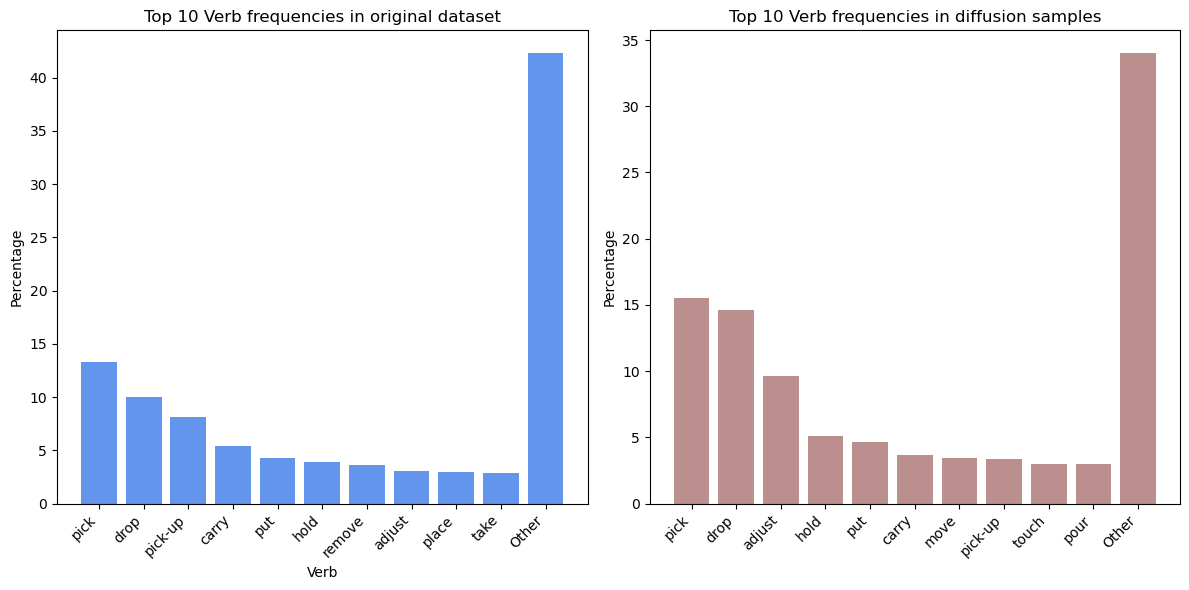

In [73]:
compare_statistics(verbs_list_original, verbs_list_diffusion, verbs, 'original dataset', 'diffusion samples', 'Verb', other=True)

### Check the objects distribution comparing original dataset and diffusion samples

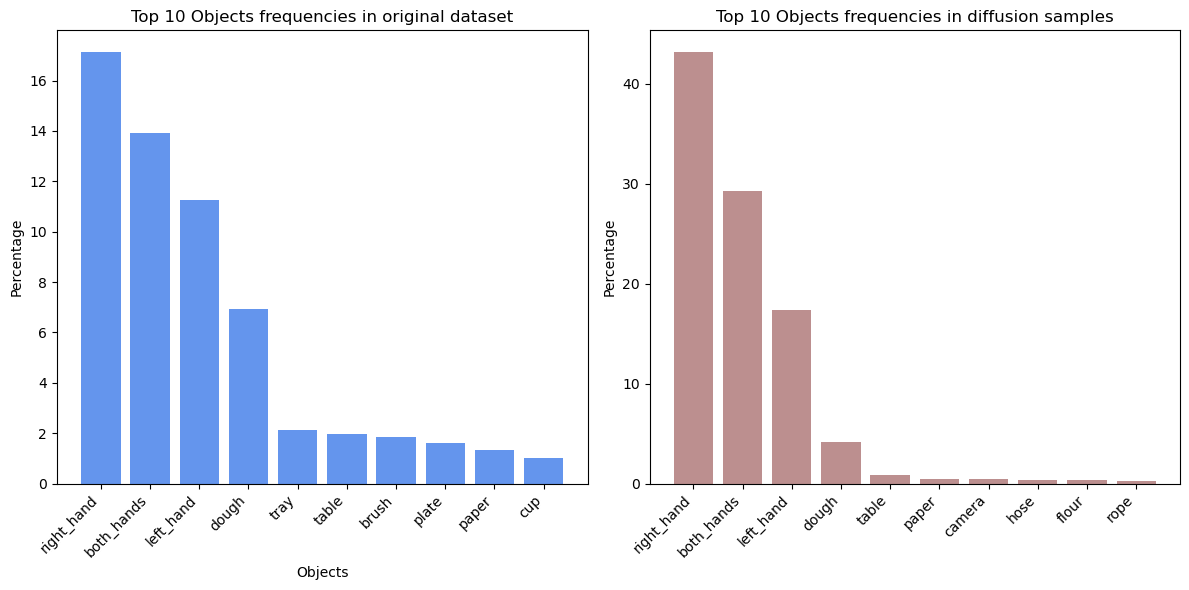

In [74]:
objs_list_original = [triplet[1].item() for triplets in triplets_original for triplet in triplets]
objs_list_diffusion = [triplet[1].item() for triplets in triplets_diffusion for triplet in triplets]

compare_statistics(objs_list_original, objs_list_diffusion, objs, 'original dataset', 'diffusion samples', 'Objects', other=False)

### Check the rels distribution comparing original dataset and diffusion samples

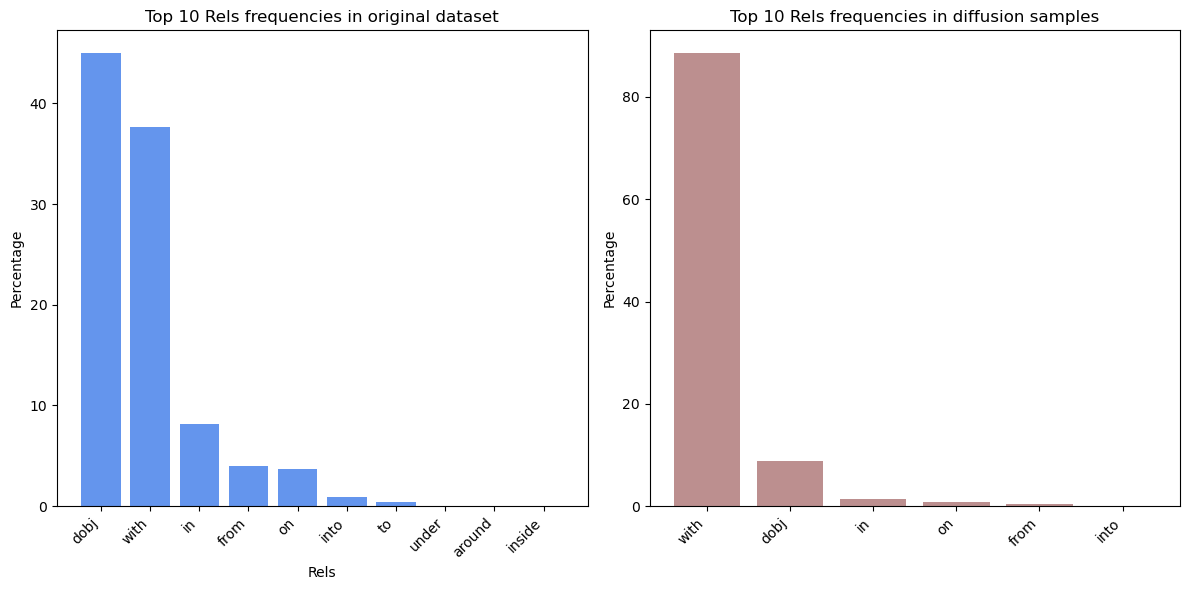

In [75]:
rels_list_original = [triplet[2].item() for triplets in triplets_original for triplet in triplets]
rels_list_diffusion = [triplet[2].item() for triplets in triplets_diffusion for triplet in triplets]

compare_statistics(rels_list_original, rels_list_diffusion, rels, 'original dataset', 'diffusion samples', 'Rels', other=False)

## Evauate diffusion model on reconstruction

In [25]:
from denoise_model import DenoiseNN
from utils_diffusion import get_denoised_samples
from utils import load_model, get_pred_triplets
import torch

diff_path = 'experiments/diffusion/diffusion2000_tsteps=1000_lr=0.0001_nlayer=8_lnorm_1722619632/checkpoints/last.ckpt'
vae_path = 'experiments/VAE1000_sep=True_fromae=True_od=256_kld=original_b=0.0005_lr=0.0001_fl=True_ex=False_eps=0.1_1719844098/checkpoints/last.ckpt'

In [4]:
from utils_diffusion import evaluate_diffusion
denoised_samples_train = evaluate_diffusion(train_loader, diff_path, vae_path, None, timesteps=1000)

Using separate mlp for verb and rels, removing shared mlp...
Using vae with focal loss...


Processing test set: 100%|██████████| 3822/3822 [46:49<00:00,  1.36it/s]


In [6]:
denoised_samples_train.size()

torch.Size([64, 256])

# Video dataset

In [100]:
from dataset_video import EASGvideo
from pathlib import Path
from torch_geometric.loader import DataLoader
import torch

with open('annts_in_new_format/' + 'verbs.txt') as f:
    verbs = [l.strip() for l in f.readlines()]
num_verbs = len(verbs)

with open('annts_in_new_format/' + 'objects.txt') as f:
    objs = [l.strip() for l in f.readlines()]
num_objs = len(objs)

with open('annts_in_new_format/' + 'relationships.txt') as f:
    rels = [l.strip() for l in f.readlines()]
num_rels = len(rels)

path_annts = Path('annts_in_new_format')
path_data = Path('data')

train_video = EASGvideo(path_annts, path_data, 'train', verbs, objs, rels)
val_video = EASGvideo(path_annts, path_data, 'val', verbs, objs, rels)

batch_size = 1
train_loader_v = DataLoader(train_video, batch_size=batch_size, shuffle=False)
val_loader_v = DataLoader(val_video, batch_size=batch_size, shuffle=False)

In [110]:
lenghts = []
for video in train_video:
    lenghts.append(len(video))

/tmp/ipykernel_73442/2466582476.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  lenghts = pd.value_counts(lenghts)
/tmp/ipykernel_73442/2466582476.py:3: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  lenghts = pd.value_counts(lenghts)


Text(0, 0.5, 'Frequency')

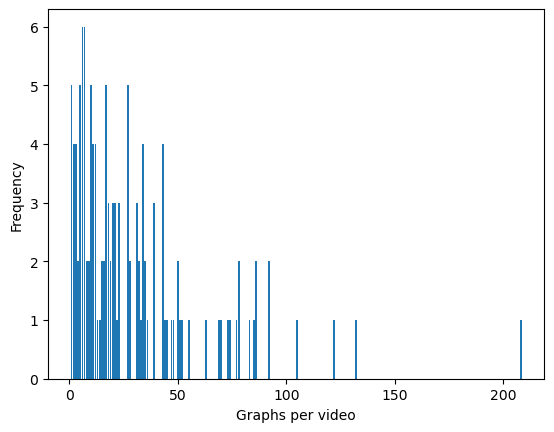

In [111]:
import pandas as pd

lenghts = pd.value_counts(lenghts)
import matplotlib.pyplot as plt
plt.bar(lenghts.index, lenghts.values)
plt.xlabel('Graphs per video')
plt.ylabel('Frequency')